In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("sampled_data.csv")

# Cek jumlah missing sebelum drop
print("Missing values per kolom:")
print(df.isna().sum())

# Hapus baris yang mengandung missing values
df_clean = df.dropna()

print("\nJumlah baris asli:", len(df))
print("Jumlah baris setelah drop missing:", len(df_clean))
print("Jumlah baris yang dibuang:", len(df) - len(df_clean))

Missing values per kolom:
killed_by               0
killer_name          1463
killer_placement     1463
killer_position_x    1463
killer_position_y    1463
map                     0
match_id                0
time                    0
victim_name             0
victim_placement      425
victim_position_x       0
victim_position_y       1
dtype: int64

Jumlah baris asli: 21225
Jumlah baris setelah drop missing: 19348
Jumlah baris yang dibuang: 1877


#STATISTIKA DESKRIPTIF

In [ ]:
# Memilih kolom numerik
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64'])

# Menghitung statistik deskriptif lengkap
desc = numeric_cols.describe(percentiles=[0.25, 0.5, 0.75]).T

# Menambahkan standar deviasi (describe tidak memunculkan sd secara default untuk semua)
desc['std'] = numeric_cols.std()

print("\nStatistika deskriptif:")
print(desc[['min', '25%', 'mean', '50%', '75%', 'std', 'max']])


Statistika deskriptif:
                    min         25%           mean        50%         75%  \
killer_placement    1.0       4.000      15.257701      11.00      21.000   
killer_position_x   0.0  334820.600  414586.808109  421057.05  527914.525   
killer_position_y   0.0  295256.900  391604.457405  378644.90  479992.175   
time               66.0     234.000     739.925367     569.00    1217.000   
victim_placement    2.0      11.000      26.153659      21.00      34.000   
victim_position_x   0.0  321004.575  405846.145268  419913.45  522854.275   
victim_position_y   0.0  292056.325  384047.375361  377343.65  478262.025   

                             std       max  
killer_placement       15.684827      95.0  
killer_position_x  146753.118073  779217.3  
killer_position_y  141230.941804  738360.7  
time                  555.071734    2123.0  
victim_placement       21.260387      99.0  
victim_position_x  156579.365106  779071.8  
victim_position_y  149987.387553  752723.8  

#HISTOGRAM VARIABEL NUMERIK

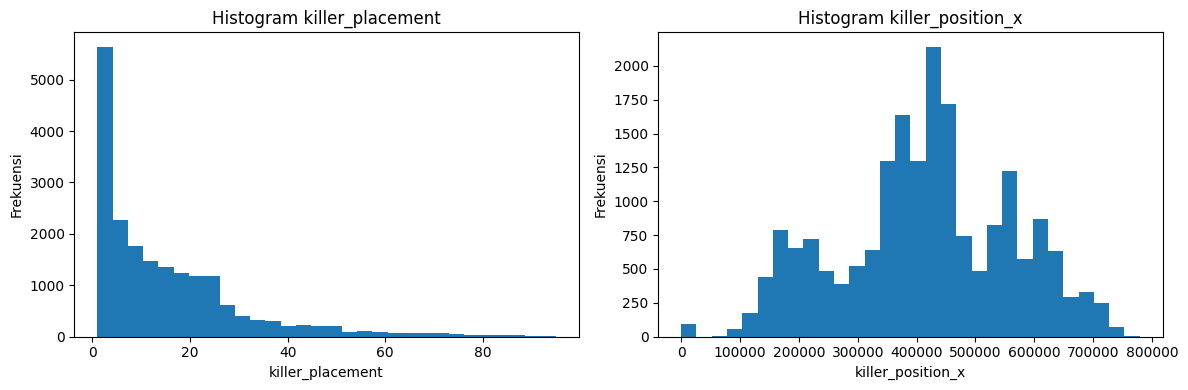

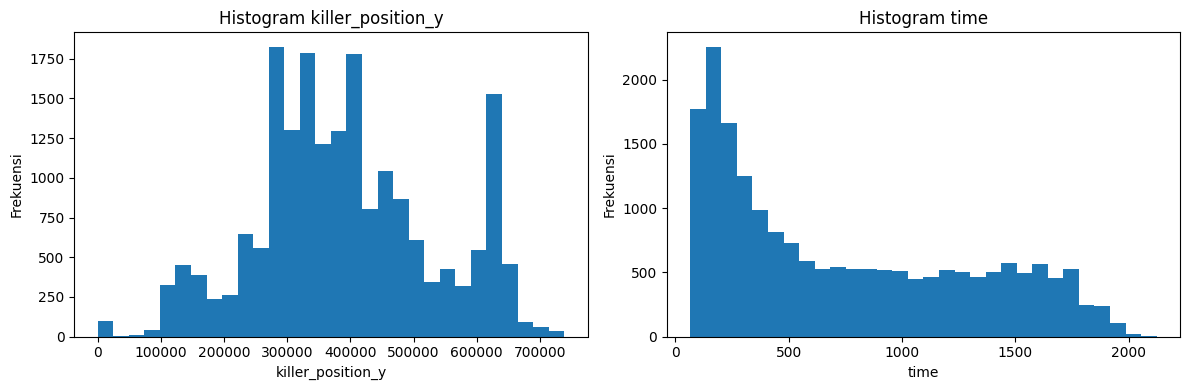

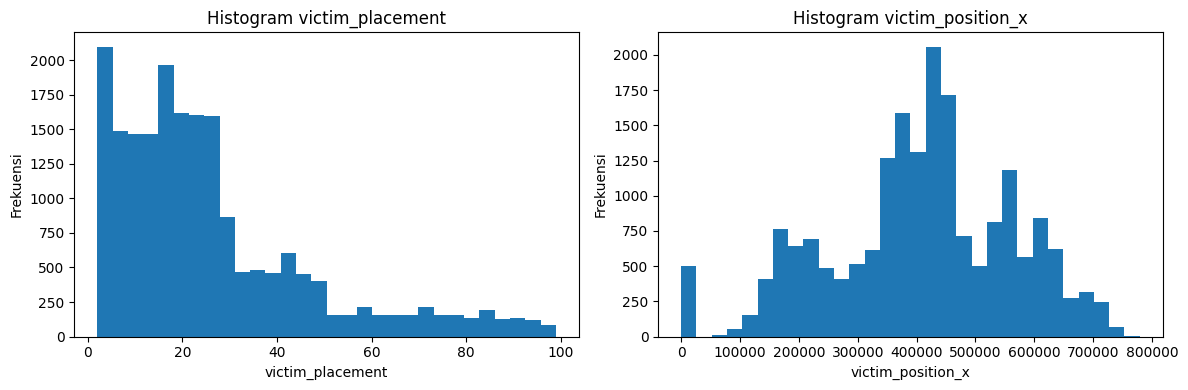

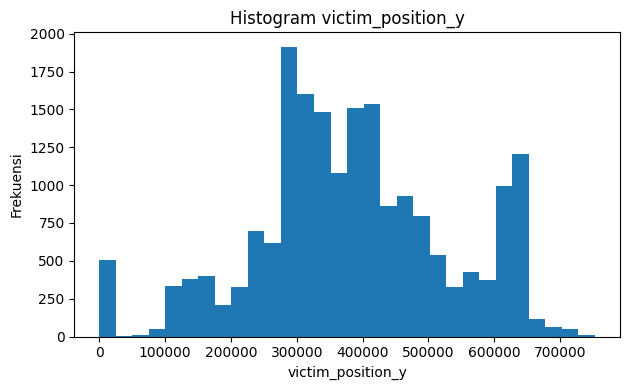

In [ ]:
import matplotlib.pyplot as plt

numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

# Loop dengan index
for i, col in enumerate(numeric_cols):
    # Setiap kali index genap → buat figure baru
    if i % 2 == 0:
        plt.figure(figsize=(12, 4))  # 2 plot dalam 1 baris

    # Tentukan posisi subplot (1 atau 2)
    subplot_position = (i % 2) + 1

    plt.subplot(1, 2, subplot_position)
    plt.hist(df_clean[col], bins=30)
    plt.title(f"Histogram {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")

    # Jika sudah 2 histogram dalam 1 baris atau sudah menyentuh kolom terakhir → tampilkan
    if (i % 2 == 1) or (i == len(numeric_cols) - 1):
        plt.tight_layout()
        plt.show()

#BOXPLOT

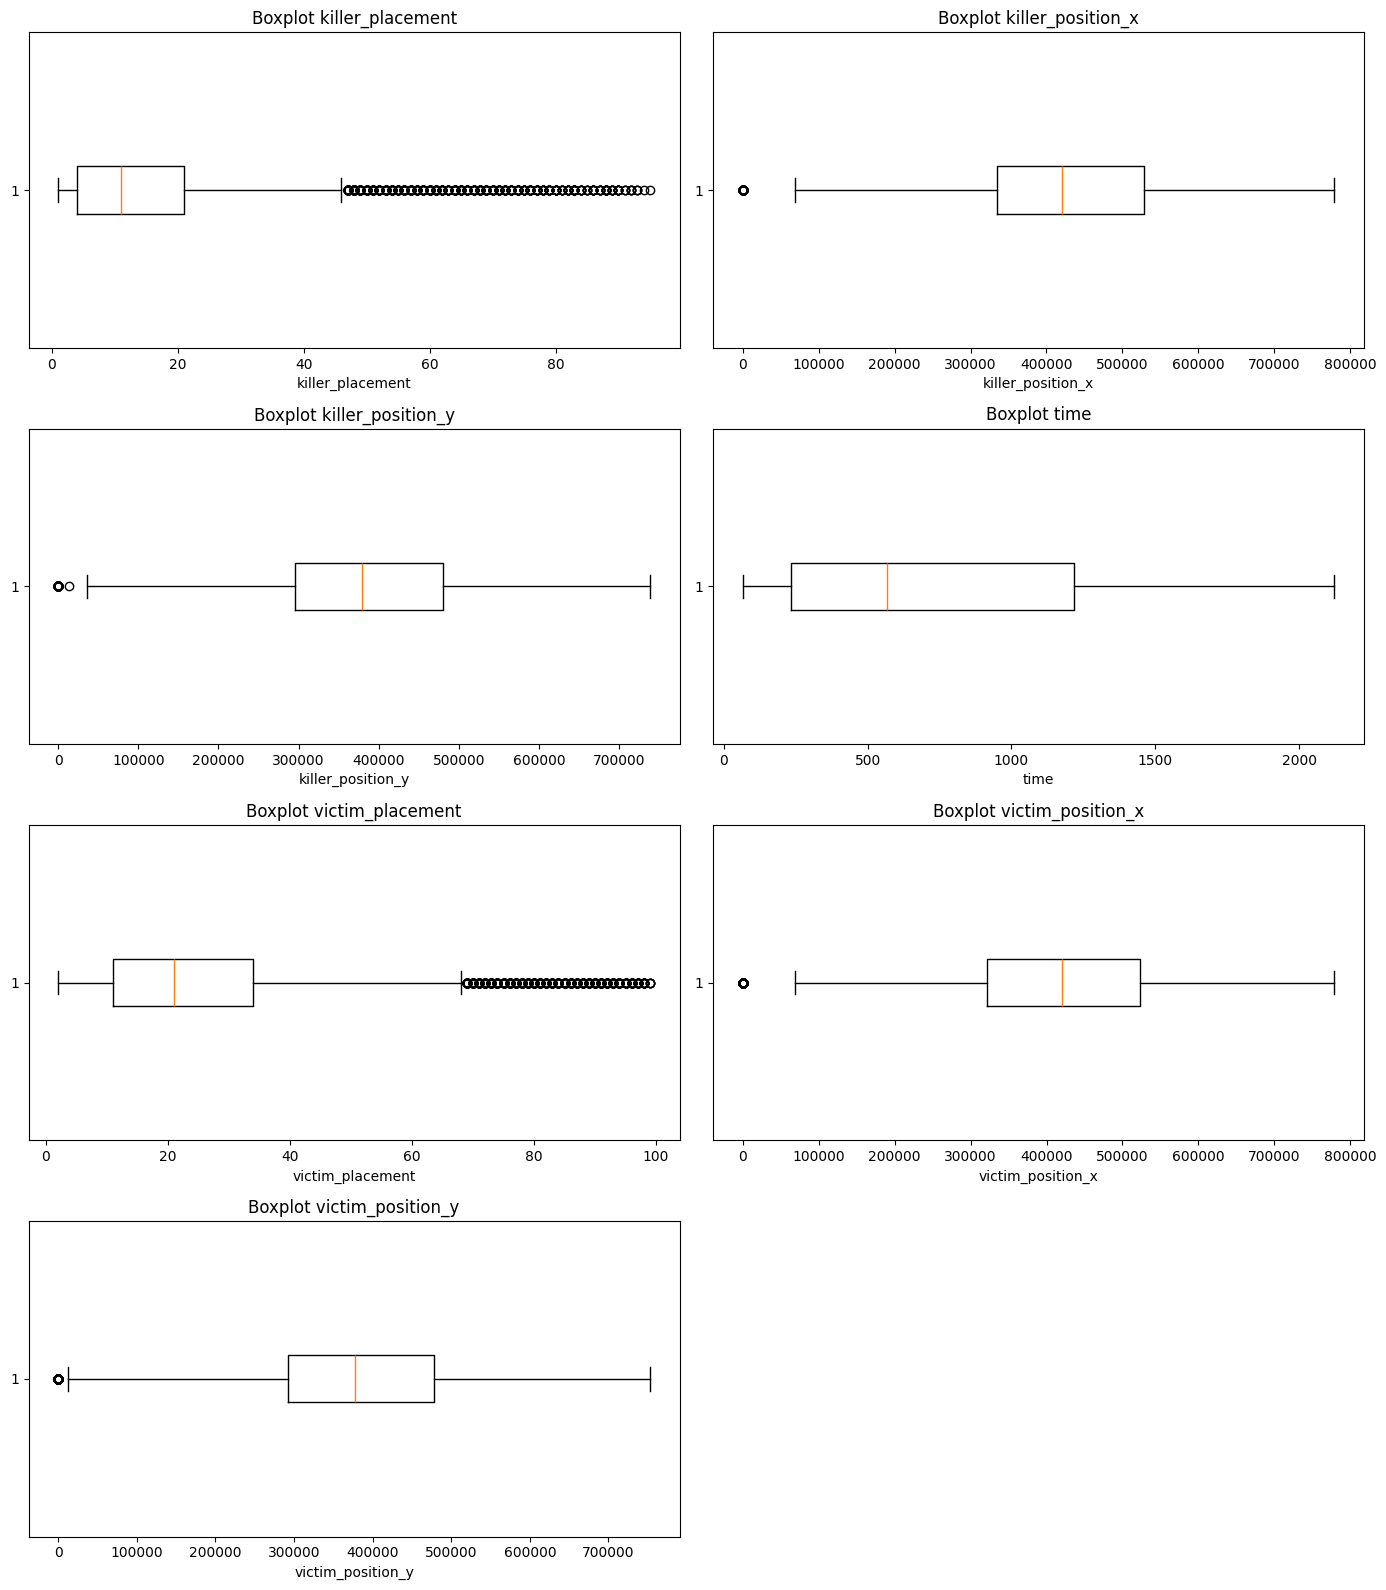

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

# Jumlah kolom numerik
n = len(numeric_cols)

# Banyak baris = ceil(n/2)
rows = int(np.ceil(n / 2))

fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))

axes = axes.flatten()  # supaya mudah di-loop

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_clean[col], vert=False)
    axes[i].set_title(f"Boxplot {col}")
    axes[i].set_xlabel(col)

# Jika variabelnya ganjil, kosongkan subplot terakhir
if n % 2 != 0:
    axes[-1].axis("off")

plt.tight_layout()
plt.show()